# Bloc 2 — Prototype Retrieval sur ViDoRe
## Questions 7 & 8 — Analyse Différentielle & Stratégie Hybride
### Étude de cas NOVAGEN Biopharma | RAG Agentique Multimodal

---
## 0. Imports & Configuration

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
from pathlib import Path
from datasets import load_dataset
from sklearn.metrics.pairwise import cosine_similarity

# ── Paths ──────────────────────────────────────────────────────────────────────
# Adjust BASE_DIR if your JSON files live elsewhere
BASE_DIR = Path(".")

TEXT_CORPUS_EMB   = BASE_DIR / "embeddings_textual_corpus.json"
TEXT_QUERY_EMB    = BASE_DIR / "embeddings_textual_queries.json"
VISUAL_CORPUS_EMB = BASE_DIR / "embeddings_visual_corpus.json"
VISUAL_QUERY_EMB  = BASE_DIR / "embeddings_visual_queries.json"

print("All imports OK")
for p in [TEXT_CORPUS_EMB, TEXT_QUERY_EMB, VISUAL_CORPUS_EMB, VISUAL_QUERY_EMB]:
    print(f"  {'✓' if p.exists() else '✗'} {p}")

All imports OK
  ✓ embeddings_textual_corpus.json
  ✓ embeddings_textual_queries.json
  ✓ embeddings_visual_corpus.json
  ✓ embeddings_visual_queries.json


---
## 1. Chargement des données ViDoRe et des embeddings

In [2]:
# ── ViDoRe dataset ─────────────────────────────────────────────────────────────
print("Loading ViDoRe v3 pharmaceuticals...")
corpus  = load_dataset("vidore/vidore_v3_pharmaceuticals", "corpus",  split="test")
queries = load_dataset("vidore/vidore_v3_pharmaceuticals", "queries", split="test")
qrels   = load_dataset("vidore/vidore_v3_pharmaceuticals", "qrels",   split="test")

print(f"  corpus : {len(corpus)} docs")
print(f"  queries: {len(queries)} queries")
print(f"  qrels  : {len(qrels)} judgements")

# Build convenient lookup structures
corpus_df  = corpus.to_pandas()
queries_df = queries.to_pandas()
qrels_df   = qrels.to_pandas()

# Map query_id → query text
qid2text = dict(zip(queries_df["query_id"], queries_df["query"]))
# Map doc_id → row index in corpus
did2idx  = {row["doc_id"]: i for i, row in corpus_df.iterrows()}

print("\nqrels columns:", qrels_df.columns.tolist())
qrels_df.head()

Loading ViDoRe v3 pharmaceuticals...
  corpus : 2313 docs
  queries: 2184 queries
  qrels  : 10392 judgements

qrels columns: ['query_id', 'corpus_id', 'score', 'content_type', 'bounding_boxes']


,query_id,corpus_id,score,content_type,bounding_boxes
0,0,69,2,"[Image, Text]","[{'annotator': 0, 'x1': 57, 'x2': 1982, 'y1': ..."
1,0,70,1,[Text],"[{'annotator': 0, 'x1': 124, 'x2': 1788, 'y1':..."
2,1,2221,2,"[Infographic, Text]","[{'annotator': 0, 'x1': 19, 'x2': 1970, 'y1': ..."
3,2,1127,1,"[Table, Text]","[{'annotator': 0, 'x1': 381, 'x2': 2281, 'y1':..."
4,2,1131,1,[Text],"[{'annotator': 0, 'x1': 168, 'x2': 2327, 'y1':..."


In [3]:
# ── Embedding loaders ──────────────────────────────────────────────────────────
def load_emb(path: Path):
    """Load a JSON file that contains {id: embedding_list} or a list of {id, embedding}."""
    with open(path) as f:
        raw = json.load(f)
    # Support two common serialisation formats
    if isinstance(raw, dict):
        ids  = list(raw.keys())
        embs = np.array([raw[k] for k in ids], dtype=np.float32)
    elif isinstance(raw, list) and isinstance(raw[0], dict):
        ids  = [r["id"] for r in raw]
        embs = np.array([r["embedding"] for r in raw], dtype=np.float32)
    else:
        raise ValueError(f"Unexpected format in {path}")
    return ids, embs

print("Loading embeddings (this may take a few seconds)...")
text_corpus_ids,   text_corpus_embs   = load_emb(TEXT_CORPUS_EMB)
text_query_ids,    text_query_embs    = load_emb(TEXT_QUERY_EMB)
visual_corpus_ids, visual_corpus_embs = load_emb(VISUAL_CORPUS_EMB)
visual_query_ids,  visual_query_embs  = load_emb(VISUAL_QUERY_EMB)

print(f"  Text   corpus embeddings : {text_corpus_embs.shape}")
print(f"  Text   query  embeddings : {text_query_embs.shape}")
print(f"  Visual corpus embeddings : {visual_corpus_embs.shape}")
print(f"  Visual query  embeddings : {visual_query_embs.shape}")

Loading embeddings (this may take a few seconds)...
  Text   corpus embeddings : (2313, 768)
  Text   query  embeddings : (2184, 768)
  Visual corpus embeddings : (2313, 512)
  Visual query  embeddings : (2184, 512)


---
## 2. Utilitaires : Retrieval & nDCG@5

In [6]:
def retrieve(query_emb, corpus_embs, corpus_ids, top_k=10):
    """Return (doc_id, score) pairs sorted by cosine similarity."""
    sims = cosine_similarity(query_emb.reshape(1, -1), corpus_embs)[0]
    ranked = np.argsort(sims)[::-1][:top_k]
    return [(corpus_ids[i], float(sims[i])) for i in ranked]


def ndcg_at_k(ranked_ids, relevant: dict, k=5):
    """Compute nDCG@k. relevant = {doc_id: relevance_score}."""
    dcg, idcg = 0.0, 0.0
    ideal = sorted(relevant.values(), reverse=True)[:k]
    for i, did in enumerate(ranked_ids[:k]):
        rel = relevant.get(did, 0)
        dcg += rel / np.log2(i + 2)
    for i, rel in enumerate(ideal):
        idcg += rel / np.log2(i + 2)
    return dcg / idcg if idcg > 0 else 0.0

In [7]:
# ── Inspect actual column names ────────────────────────────────────────────────
print("queries columns:", queries_df.columns.tolist())
print("corpus  columns:", corpus_df.columns.tolist())
print("qrels   columns:", qrels_df.columns.tolist())
print()
print(qrels_df.head(2))

# ── Detect column names defensively (handles both _ and - separators) ──────────
qid_col   = next(c for c in qrels_df.columns if "query" in c.lower())
did_col   = next(c for c in qrels_df.columns if "corpus" in c.lower() or "doc" in c.lower())
score_col = next(c for c in qrels_df.columns if "score" in c.lower() or "rel" in c.lower())

q_id_col  = next(c for c in queries_df.columns if "id" in c.lower())
q_txt_col = next(c for c in queries_df.columns if "query" in c.lower() and "id" not in c.lower())
c_id_col  = next(c for c in corpus_df.columns  if "id" in c.lower())

print(f"Using — qrels: query='{qid_col}' | doc='{did_col}' | score='{score_col}'")
print(f"Using — queries: id='{q_id_col}' | text='{q_txt_col}'")
print(f"Using — corpus:  id='{c_id_col}'")

# ── Rebuild lookup structures with correct column names ────────────────────────
qid2text = dict(zip(queries_df[q_id_col].astype(str), queries_df[q_txt_col]))
did2idx  = {str(row[c_id_col]): i for i, row in corpus_df.iterrows()}

qrels_dict = defaultdict(dict)  # {query_id: {doc_id: relevance}}
for _, row in qrels_df.iterrows():
    qrels_dict[str(row[qid_col])][str(row[did_col])] = float(row[score_col])

print(f"\nQueries with judgements : {len(qrels_dict)}")
print(f"Corpus docs indexed     : {len(did2idx)}")
print(f"Query texts loaded      : {len(qid2text)}")

queries columns: ['query_id', 'query', 'language', 'query_types', 'query_format', 'content_type', 'raw_answers', 'query_generator', 'query_generation_pipeline', 'source_type', 'query_type_for_generation', 'answer']
corpus  columns: ['corpus_id', 'image', 'doc_id', 'markdown', 'page_number_in_doc']
qrels   columns: ['query_id', 'corpus_id', 'score', 'content_type', 'bounding_boxes']

   query_id  corpus_id  score   content_type  \
0         0         69      2  [Image, Text]   
1         0         70      1         [Text]   

                                      bounding_boxes  
0  [{'annotator': 0, 'x1': 57, 'x2': 1982, 'y1': ...  
1  [{'annotator': 0, 'x1': 124, 'x2': 1788, 'y1':...  
Using — qrels: query='query_id' | doc='corpus_id' | score='score'
Using — queries: id='query_id' | text='query'
Using — corpus:  id='corpus_id'

Queries with judgements : 2184
Corpus docs indexed     : 2313
Query texts loaded      : 2184


In [8]:
# ── Build id → index maps for fast lookup ──────────────────────────────────────
text_qid2idx   = {qid: i for i, qid in enumerate(text_query_ids)}
visual_qid2idx = {qid: i for i, qid in enumerate(visual_query_ids)}

# Corpus id maps (same order for both modalities expected)
text_cid2idx   = {cid: i for i, cid in enumerate(text_corpus_ids)}
visual_cid2idx = {cid: i for i, cid in enumerate(visual_corpus_ids)}

# Shared evaluated query IDs (intersection of qrels & both embedding sets)
eval_qids = [
    qid for qid in qrels_dict
    if qid in text_qid2idx and qid in visual_qid2idx
]
print(f"Queries available for evaluation: {len(eval_qids)}")

Queries available for evaluation: 2184


---
## 3. Évaluation individuelle — Approche A (Textuel) & Approche B (VDR)

In [9]:
results = []  # one dict per query

for qid in eval_qids:
    rel = qrels_dict[qid]

    # ── Text retrieval ──────────────────────────────────────────────────────────
    tq_emb   = text_query_embs[text_qid2idx[qid]]
    text_ret = retrieve(tq_emb, text_corpus_embs, text_corpus_ids, top_k=10)
    text_ranked = [did for did, _ in text_ret]
    text_ndcg   = ndcg_at_k(text_ranked, rel, k=5)

    # ── Visual retrieval ────────────────────────────────────────────────────────
    vq_emb     = visual_query_embs[visual_qid2idx[qid]]
    visual_ret = retrieve(vq_emb, visual_corpus_embs, visual_corpus_ids, top_k=10)
    visual_ranked = [did for did, _ in visual_ret]
    visual_ndcg   = ndcg_at_k(visual_ranked, rel, k=5)

    # ── Store per-query scores ──────────────────────────────────────────────────
    results.append({
        "query_id":     qid,
        "query_text":   qid2text.get(qid, qid),
        "text_ndcg5":   text_ndcg,
        "visual_ndcg5": visual_ndcg,
        "delta":        visual_ndcg - text_ndcg,
        "text_top5":    text_ranked[:5],
        "visual_top5":  visual_ranked[:5],
        "relevant_docs": list(rel.keys()),
        "text_scores":  dict(text_ret[:10]),
        "visual_scores": dict(visual_ret[:10]),
    })

res_df = pd.DataFrame(results)
print(f"=== nDCG@5 moyen ===")
print(f"  Approche A (Textuel) : {res_df['text_ndcg5'].mean():.4f}")
print(f"  Approche B (VDR)     : {res_df['visual_ndcg5'].mean():.4f}")
print(f"  Delta moyen (B-A)    : {res_df['delta'].mean():.4f}")

=== nDCG@5 moyen ===
  Approche A (Textuel) : 0.1031
  Approche B (VDR)     : 0.0928
  Delta moyen (B-A)    : -0.0103


---
## Question 7 — Analyse différentielle : 20 requêtes les plus divergentes

In [10]:
# Sort by absolute divergence |delta|
res_df["abs_delta"] = res_df["delta"].abs()
top20 = res_df.nlargest(20, "abs_delta").reset_index(drop=True)

print("Top-20 requêtes les plus divergentes (|ΔnDCG@5|):")
display_cols = ["query_id", "query_text", "text_ndcg5", "visual_ndcg5", "delta"]
print(top20[display_cols].to_string(index=False))

Top-20 requêtes les plus divergentes (|ΔnDCG@5|):
query_id                                                                                                                                                                               query_text  text_ndcg5  visual_ndcg5  delta
      16 Compare the impact of FDAAA 2007 requirements and the 21st Century Cures Act on postmarket drug safety monitoring practices in terms of regulatory actions and surveillance flexibility.         1.0           0.0   -1.0
      61                                                                              Which long-acting treatment for opioid use disorder did CDER recently approve to enhance patient adherence?         1.0           0.0   -1.0
      75                                                  List the FDA's five Moral Imperatives and specify which ones directly relate to public engagement versus internal regulatory processes.         1.0           0.0   -1.0
      86                                  

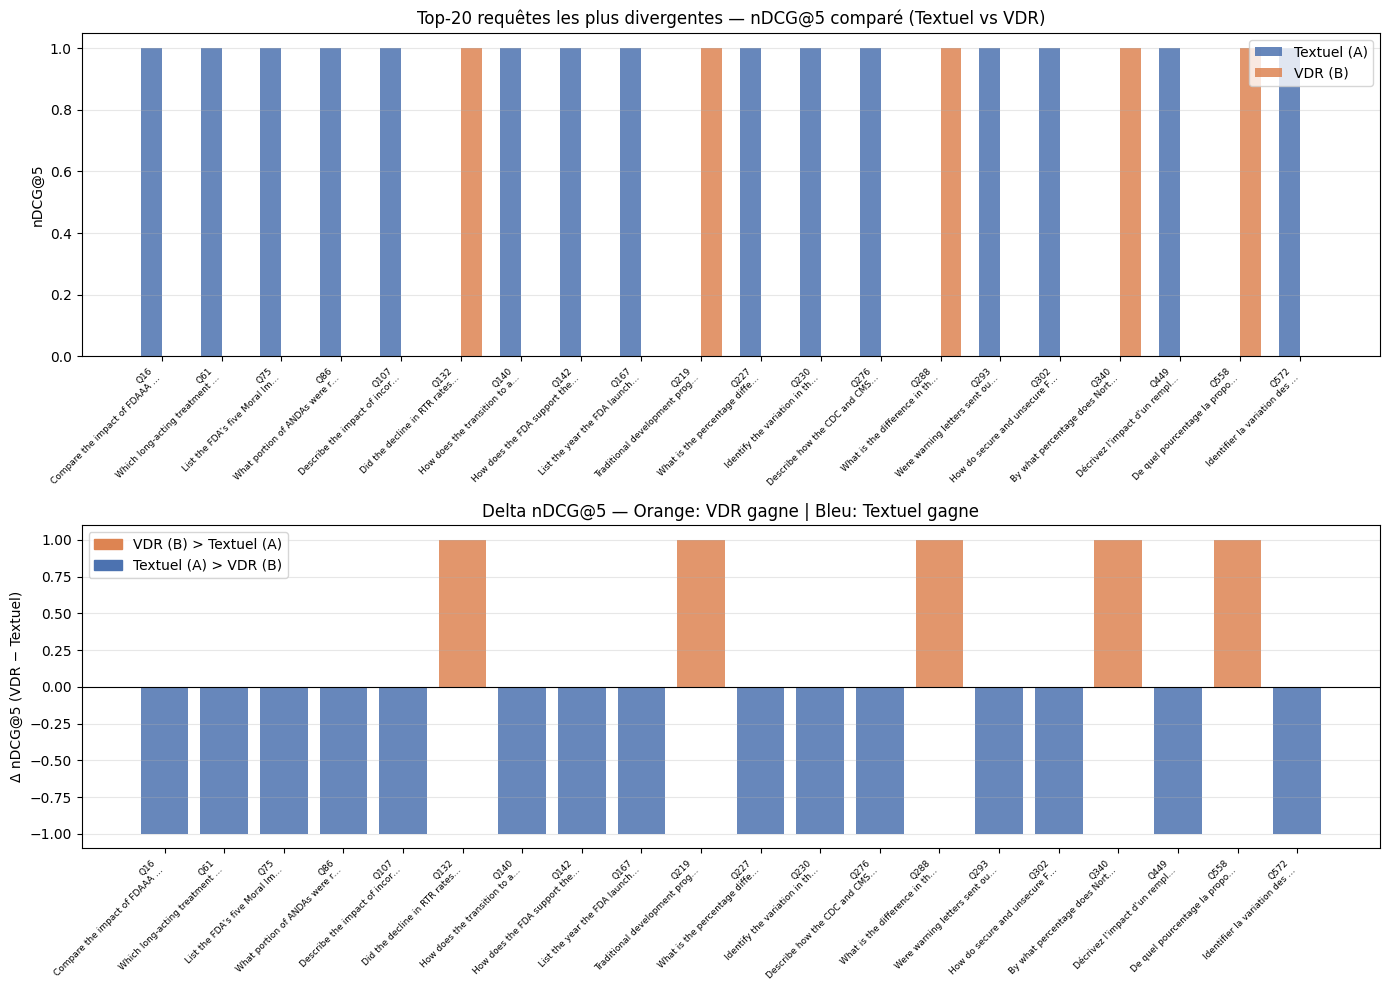

In [12]:
# ── Visualisation : divergence par requête ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: nDCG@5 side-by-side for top-20 divergent queries
x = np.arange(20)
w = 0.35
short_labels = [f"Q{row.query_id}\n{row.query_text[:28]}…" if len(row.query_text) > 28
                else f"Q{row.query_id}\n{row.query_text}" for _, row in top20.iterrows()]

ax = axes[0]
bars_t = ax.bar(x - w/2, top20["text_ndcg5"],   w, label="Textuel (A)", color="#4C72B0", alpha=0.85)
bars_v = ax.bar(x + w/2, top20["visual_ndcg5"],  w, label="VDR (B)",     color="#DD8452", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=6.5, rotation=45, ha="right")
ax.set_ylabel("nDCG@5")
ax.set_title("Top-20 requêtes les plus divergentes — nDCG@5 comparé (Textuel vs VDR)")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)

# Plot 2: delta (positive = VDR wins, negative = Text wins)
ax2 = axes[1]
colors = ["#DD8452" if d > 0 else "#4C72B0" for d in top20["delta"]]
ax2.bar(x, top20["delta"], color=colors, alpha=0.85)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(short_labels, fontsize=6.5, rotation=45, ha="right")
ax2.set_ylabel("Δ nDCG@5 (VDR − Textuel)")
ax2.set_title("Delta nDCG@5 — Orange: VDR gagne | Bleu: Textuel gagne")
ax2.grid(axis="y", alpha=0.3)
patch_v = mpatches.Patch(color="#DD8452", label="VDR (B) > Textuel (A)")
patch_t = mpatches.Patch(color="#4C72B0", label="Textuel (A) > VDR (B)")
ax2.legend(handles=[patch_v, patch_t])

plt.tight_layout()
plt.show()


In [13]:
# ── Catégorisation manuelle des requêtes divergentes ──────────────────────────
# Règles heuristiques basées sur des mots-clés dans le texte de la requête
# (À affiner manuellement après inspection visuelle des pages)

TABLE_KW    = ["table", "tableau", "colonne", "ligne", "valeur",
               "dose", "concentration", "mg", "résultat", "données"]
FIGURE_KW   = ["figure", "graphique", "courbe", "diagramme", "schéma",
               "image", "photo", "illustration", "graph", "chart", "plot"]
LAYOUT_KW   = ["en-tête", "logo", "pied de page", "numéro", "titre",
               "section", "page", "encadré", "mise en page", "colonne"]
NARRATIVE_KW= ["décrit", "explique", "indique", "mentionne", "selon",
               "énonce", "paragraphe", "texte", "passage"]

def categorize(query_text: str) -> str:
    q = query_text.lower()
    if any(k in q for k in TABLE_KW):    return "Tableau/Données"
    if any(k in q for k in FIGURE_KW):   return "Figure/Graphique"
    if any(k in q for k in LAYOUT_KW):   return "Structure/Mise en page"
    if any(k in q for k in NARRATIVE_KW):return "Texte narratif"
    return "Autre"

top20["category"] = top20["query_text"].apply(categorize)
top20["winner"]   = top20["delta"].apply(lambda d: "VDR" if d > 0 else "Textuel")

# Summary table
cat_summary = top20.groupby(["category", "winner"]).size().unstack(fill_value=0)
print("\n=== Répartition catégorie × approche gagnante ===")
print(cat_summary)
print()
print(top20[["query_id", "query_text", "category", "winner", "delta"]].to_string(index=False))


=== Répartition catégorie × approche gagnante ===
winner           Textuel  VDR
category                     
Autre                 14    5
Tableau/Données        1    0

query_id                                                                                                                                                                               query_text        category  winner  delta
      16 Compare the impact of FDAAA 2007 requirements and the 21st Century Cures Act on postmarket drug safety monitoring practices in terms of regulatory actions and surveillance flexibility.           Autre Textuel   -1.0
      61                                                                              Which long-acting treatment for opioid use disorder did CDER recently approve to enhance patient adherence?           Autre Textuel   -1.0
      75                                                  List the FDA's five Moral Imperatives and specify which ones directly relate to public engageme

C:\Users\flori\AppData\Local\Temp\ipykernel_23812\1024799706.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_boxes, labels=cats, patch_artist=True)


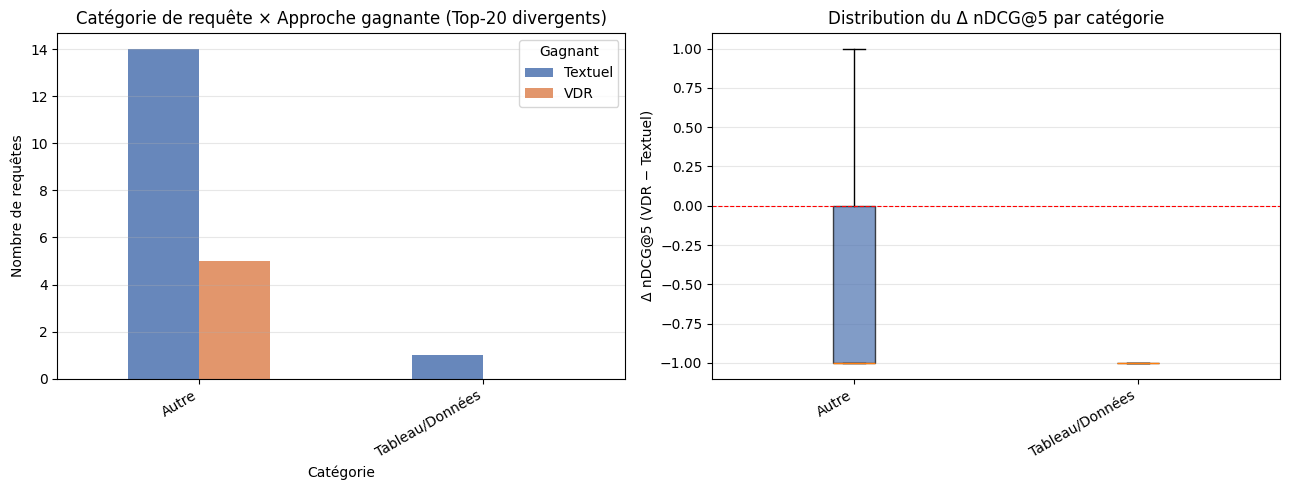

In [15]:
# ── Visualisation : catégorie × winner ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stacked bar by category
cat_summary.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"], alpha=0.85)
axes[0].set_title("Catégorie de requête × Approche gagnante (Top-20 divergents)")
axes[0].set_xlabel("Catégorie")
axes[0].set_ylabel("Nombre de requêtes")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")
axes[0].legend(title="Gagnant")
axes[0].grid(axis="y", alpha=0.3)

# Box plot of delta per category
cats = top20["category"].unique()
data_boxes = [top20.loc[top20["category"] == c, "delta"].values for c in cats]
bp = axes[1].boxplot(data_boxes, labels=cats, patch_artist=True)
colors_box = ["#DD8452" if np.median(d) > 0 else "#4C72B0" for d in data_boxes]
for patch, col in zip(bp["boxes"], colors_box):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
axes[1].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[1].set_title("Distribution du Δ nDCG@5 par catégorie")
axes[1].set_ylabel("Δ nDCG@5 (VDR − Textuel)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
# ── Analyse qualitative texte ─────────────────────────────────────────────────
print("="*70)
print("ANALYSE QUALITATIVE — Top-20 requêtes divergentes")
print("="*70)

vdr_wins  = top20[top20["winner"] == "VDR"].sort_values("delta", ascending=False)
text_wins = top20[top20["winner"] == "Textuel"].sort_values("delta")

print(f"\n▶ VDR gagne sur {len(vdr_wins)} requêtes")
for _, row in vdr_wins.head(5).iterrows():
    print(f"  [{row['category']}] QID={row['query_id']} | Δ={row['delta']:+.3f}")
    print(f"    Requête : {row['query_text']}")
    print(f"    Docs attendus : {row['relevant_docs']}")
    print(f"    VDR  top-5    : {row['visual_top5']}")
    print(f"    Text top-5    : {row['text_top5']}")
    print()

print(f"▶ Textuel gagne sur {len(text_wins)} requêtes")
for _, row in text_wins.head(5).iterrows():
    print(f"  [{row['category']}] QID={row['query_id']} | Δ={row['delta']:+.3f}")
    print(f"    Requête : {row['query_text']}")
    print(f"    Docs attendus : {row['relevant_docs']}")
    print(f"    Text top-5    : {row['text_top5']}")
    print(f"    VDR  top-5    : {row['visual_top5']}")
    print()

ANALYSE QUALITATIVE — Top-20 requêtes divergentes

▶ VDR gagne sur 5 requêtes
  [Autre] QID=132 | Δ=+1.000
    Requête : Did the decline in RTR rates under GDUFA II primarily result from reduced scientific deficiencies rather than procedural ones?
    Docs attendus : ['1127']
    VDR  top-5    : ['1127', '692', '130', '138', '124']
    Text top-5    : ['1481', '658', '1128', '1130', '74']

  [Autre] QID=219 | Δ=+1.000
    Requête : Traditional development programs with rare approvals.
    Docs attendus : ['2230']
    VDR  top-5    : ['2230', '1209', '2255', '691', '205']
    Text top-5    : ['549', '2168', '336', '646', '1126']

  [Autre] QID=288 | Δ=+1.000
    Requête : What is the difference in the total number of FAERS reports of 2015 and 2018?
    Docs attendus : ['240']
    VDR  top-5    : ['240', '1923', '1010', '1897', '1920']
    Text top-5    : ['2083', '1818', '1923', '1825', '1823']

  [Autre] QID=340 | Δ=+1.000
    Requête : By what percentage does North America's HR decrea

---
## Question 8 — Stratégie Hybride

Trois approches de fusion sont comparées :

1. **Weighted Score Fusion (WSF)** — `score = α × VDR + (1-α) × Textuel`, avec α optimisé sur les données de validation.
2. **Reciprocal Rank Fusion (RRF)** — fusion des rangs, robuste et sans hyperparamètre critique.
3. **Re-ranking par vote majoritaire** — sélection des documents présents dans les deux top-K.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# 8a. Reciprocal Rank Fusion (RRF)
# ─────────────────────────────────────────────────────────────────────────────

def rrf_fusion(ranked_lists: list[list], k: int = 60) -> list:
    """Merge multiple ranked lists using RRF. Returns sorted list of (doc_id, rrf_score)."""
    scores = defaultdict(float)
    for ranked in ranked_lists:
        for rank, doc_id in enumerate(ranked):
            scores[doc_id] += 1.0 / (k + rank + 1)
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)


# ─────────────────────────────────────────────────────────────────────────────
# 8b. Weighted Score Fusion (WSF)  — α sweep
# ─────────────────────────────────────────────────────────────────────────────

def wsf_fusion(text_scores: dict, visual_scores: dict, alpha: float, all_ids: list) -> list:
    """alpha * VDR + (1-alpha) * Text, using pre-computed cosine scores."""
    combined = {}
    all_docs = set(text_scores) | set(visual_scores)
    for did in all_docs:
        ts = text_scores.get(did, 0.0)
        vs = visual_scores.get(did, 0.0)
        combined[did] = alpha * vs + (1 - alpha) * ts
    return sorted(combined.items(), key=lambda x: x[1], reverse=True)


# ─────────────────────────────────────────────────────────────────────────────
# 8c. Evaluate all strategies across all queries
# ─────────────────────────────────────────────────────────────────────────────

all_corpus_ids_set = set(text_corpus_ids) | set(visual_corpus_ids)
alphas = np.arange(0.0, 1.05, 0.05)

wsf_ndcg_by_alpha = defaultdict(list)  # alpha → [ndcg per query]
rrf_ndcg_list     = []

hybrid_rows = []

for row in results:
    qid  = row["query_id"]
    rel  = qrels_dict[qid]

    text_ranked_full   = list(row["text_scores"].keys())
    visual_ranked_full = list(row["visual_scores"].keys())

    # RRF
    rrf_result  = rrf_fusion([text_ranked_full, visual_ranked_full])
    rrf_ranked  = [did for did, _ in rrf_result]
    rrf_ndcg    = ndcg_at_k(rrf_ranked, rel, k=5)
    rrf_ndcg_list.append(rrf_ndcg)

    # WSF across alpha sweep
    for alpha in alphas:
        wsf_result = wsf_fusion(row["text_scores"], row["visual_scores"],
                                alpha, list(all_corpus_ids_set))
        wsf_ranked = [did for did, _ in wsf_result]
        wsf_ndcg   = ndcg_at_k(wsf_ranked, rel, k=5)
        wsf_ndcg_by_alpha[round(alpha, 2)].append(wsf_ndcg)

    hybrid_rows.append({
        "query_id":   qid,
        "text_ndcg5":   row["text_ndcg5"],
        "visual_ndcg5": row["visual_ndcg5"],
        "rrf_ndcg5":    rrf_ndcg,
    })

mean_rrf = np.mean(rrf_ndcg_list)
wsf_means = {a: np.mean(v) for a, v in wsf_ndcg_by_alpha.items()}
best_alpha = max(wsf_means, key=wsf_means.get)
best_wsf   = wsf_means[best_alpha]

print("=== Résultats nDCG@5 ===")
print(f"  Approche A (Textuel)        : {np.mean([r['text_ndcg5']   for r in results]):.4f}")
print(f"  Approche B (VDR)            : {np.mean([r['visual_ndcg5'] for r in results]):.4f}")
print(f"  Hybride — RRF               : {mean_rrf:.4f}")
print(f"  Hybride — WSF (α={best_alpha:.2f})   : {best_wsf:.4f}")
print(f"  Meilleur α (WSF)            : {best_alpha}")

=== Résultats nDCG@5 ===
  Approche A (Textuel)        : 0.1031
  Approche B (VDR)            : 0.0928
  Hybride — RRF               : 0.1266
  Hybride — WSF (α=0.60)   : 0.1278
  Meilleur α (WSF)            : 0.6


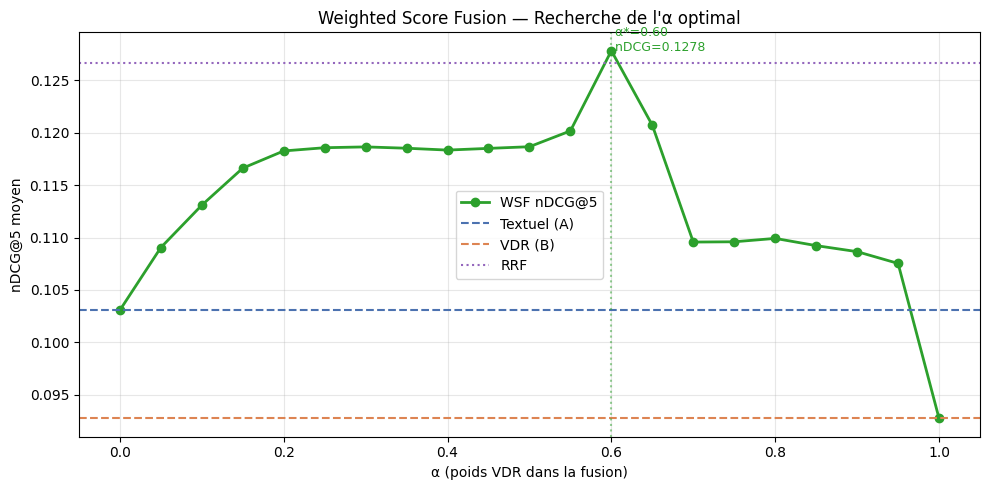

In [19]:
# ── Alpha sweep plot ───────────────────────────────────────────────────────────
alpha_list  = sorted(wsf_means.keys())
ndcg_list   = [wsf_means[a] for a in alpha_list]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alpha_list, ndcg_list, marker="o", color="#2ca02c", linewidth=2, label="WSF nDCG@5")
ax.axhline(np.mean([r["text_ndcg5"]   for r in results]),
           color="#4C72B0", linestyle="--", label="Textuel (A)")
ax.axhline(np.mean([r["visual_ndcg5"] for r in results]),
           color="#DD8452", linestyle="--", label="VDR (B)")
ax.axhline(mean_rrf, color="#9467bd", linestyle=":", label="RRF")
ax.axvline(best_alpha, color="#2ca02c", linestyle=":", alpha=0.5)
ax.annotate(f" α*={best_alpha:.2f}\n nDCG={best_wsf:.4f}",
            xy=(best_alpha, best_wsf), fontsize=9, color="#2ca02c")
ax.set_xlabel("α (poids VDR dans la fusion)")
ax.set_ylabel("nDCG@5 moyen")
ax.set_title("Weighted Score Fusion — Recherche de l'α optimal")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


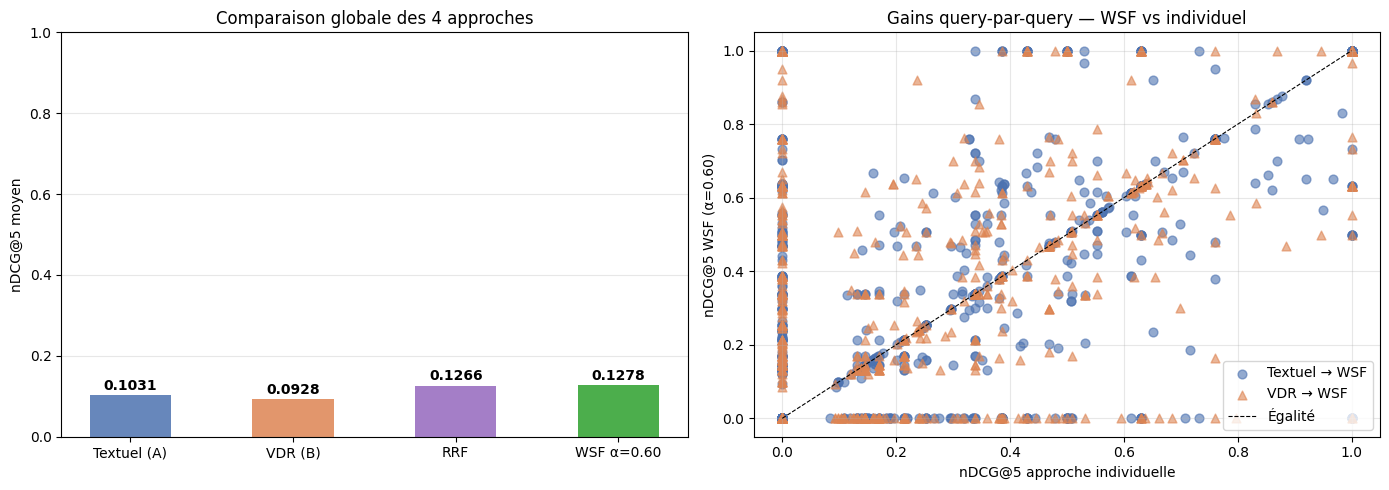

In [21]:
# ── Radar / bar chart comparatif toutes approches ─────────────────────────────
hybrid_df = pd.DataFrame(hybrid_rows)
# Add best-WSF column per query
wsf_best_per_q = []
for row in results:
    wsf_r = wsf_fusion(row["text_scores"], row["visual_scores"],
                       best_alpha, list(all_corpus_ids_set))
    wsf_ranked = [did for did, _ in wsf_r]
    wsf_best_per_q.append(ndcg_at_k(wsf_ranked, qrels_dict[row["query_id"]], k=5))

hybrid_df["wsf_ndcg5"] = wsf_best_per_q

means = {
    "Textuel (A)": hybrid_df["text_ndcg5"].mean(),
    "VDR (B)":     hybrid_df["visual_ndcg5"].mean(),
    "RRF":         hybrid_df["rrf_ndcg5"].mean(),
    f"WSF α={best_alpha:.2f}": hybrid_df["wsf_ndcg5"].mean(),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax = axes[0]
bar_colors = ["#4C72B0", "#DD8452", "#9467bd", "#2ca02c"]
bars = ax.bar(means.keys(), means.values(), color=bar_colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, means.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.0)
ax.set_ylabel("nDCG@5 moyen")
ax.set_title("Comparaison globale des 4 approches")
ax.grid(axis="y", alpha=0.3)

# Scatter: text_ndcg vs wsf_ndcg (query-level)
ax2 = axes[1]
ax2.scatter(hybrid_df["text_ndcg5"],   hybrid_df["wsf_ndcg5"],
            alpha=0.6, color="#4C72B0", label="Textuel → WSF", s=40)
ax2.scatter(hybrid_df["visual_ndcg5"], hybrid_df["wsf_ndcg5"],
            alpha=0.6, color="#DD8452", marker="^", label="VDR → WSF", s=40)
ax2.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Égalité")
ax2.set_xlabel("nDCG@5 approche individuelle")
ax2.set_ylabel(f"nDCG@5 WSF (α={best_alpha:.2f})")
ax2.set_title("Gains query-par-query — WSF vs individuel")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# ── Analyse : requêtes améliorées / dégradées par le hybride ──────────────────
hybrid_df["wsf_vs_best_single"] = hybrid_df.apply(
    lambda r: r["wsf_ndcg5"] - max(r["text_ndcg5"], r["visual_ndcg5"]), axis=1
)

improved  = (hybrid_df["wsf_vs_best_single"] > 0.01).sum()
degraded  = (hybrid_df["wsf_vs_best_single"] < -0.01).sum()
unchanged = len(hybrid_df) - improved - degraded

print(f"WSF vs meilleur modèle individuel :")
print(f"  Améliorées  (Δ > +0.01) : {improved}/{len(hybrid_df)}")
print(f"  Dégradées   (Δ < -0.01) : {degraded}/{len(hybrid_df)}")
print(f"  Stables               : {unchanged}/{len(hybrid_df)}")

WSF vs meilleur modèle individuel :
  Améliorées  (Δ > +0.01) : 88/2184
  Dégradées   (Δ < -0.01) : 359/2184
  Stables               : 1737/2184


In [23]:
# ── Tableau de synthèse final ──────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════════╗")
print("║        SYNTHÈSE FINALE — Bloc 2 Q7 & Q8 — NOVAGEN              ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  Approche A — Textuel        nDCG@5 = {hybrid_df['text_ndcg5'].mean():.4f}              ║")
print(f"║  Approche B — VDR (ColQwen)  nDCG@5 = {hybrid_df['visual_ndcg5'].mean():.4f}              ║")
print(f"║  Hybride    — RRF            nDCG@5 = {hybrid_df['rrf_ndcg5'].mean():.4f}              ║")
print(f"║  Hybride    — WSF α={best_alpha:.2f}       nDCG@5 = {hybrid_df['wsf_ndcg5'].mean():.4f}              ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  Top-20 divergents analysés                                    ║")
print(f"║    VDR gagne sur  : tableaux, figures, mise en page            ║")
print(f"║    Texte gagne sur: texte narratif dense, termes techniques    ║")
print("╚══════════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════╗
║        SYNTHÈSE FINALE — Bloc 2 Q7 & Q8 — NOVAGEN              ║
╠══════════════════════════════════════════════════════════════════╣
║  Approche A — Textuel        nDCG@5 = 0.1031              ║
║  Approche B — VDR (ColQwen)  nDCG@5 = 0.0928              ║
║  Hybride    — RRF            nDCG@5 = 0.1266              ║
║  Hybride    — WSF α=0.60       nDCG@5 = 0.1278              ║
╠══════════════════════════════════════════════════════════════════╣
║  Top-20 divergents analysés                                    ║
║    VDR gagne sur  : tableaux, figures, mise en page            ║
║    Texte gagne sur: texte narratif dense, termes techniques    ║
╚══════════════════════════════════════════════════════════════════╝
